###CAR SALES DATA ANALYSIS 

##IMPORTING LIBRARIES

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

##LAODING DATASET

In [3]:
df= pd.read_csv(r'vehicle_sales.csv')
df.head()

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705
4,VW,Polo,1.0,Petrol,2006,127869,4101


##EXPLORING RAW DATA

In [4]:
df.shape

(50000, 7)

In [5]:
df.size

350000

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Manufacturer         50000 non-null  str    
 1   Model                50000 non-null  str    
 2   Engine size          50000 non-null  float64
 3   Fuel type            50000 non-null  str    
 4   Year of manufacture  50000 non-null  int64  
 5   Mileage              50000 non-null  int64  
 6   Price                50000 non-null  int64  
dtypes: float64(1), int64(3), str(3)
memory usage: 3.4 MB


In [7]:
df.columns

Index(['Manufacturer', 'Model', 'Engine size', 'Fuel type',
       'Year of manufacture', 'Mileage', 'Price'],
      dtype='str')

In [8]:
df.dtypes

Manufacturer               str
Model                      str
Engine size            float64
Fuel type                  str
Year of manufacture      int64
Mileage                  int64
Price                    int64
dtype: object

In [9]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
49995    False
49996    False
49997    False
49998    False
49999    False
Length: 50000, dtype: bool

In [10]:
df.isnull()

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
49995,False,False,False,False,False,False,False
49996,False,False,False,False,False,False,False
49997,False,False,False,False,False,False,False
49998,False,False,False,False,False,False,False


In [11]:
df.Mileage

0        127300
1         57850
2         39190
3        210814
4        127869
          ...  
49995     28664
49996    105120
49997      4030
49998     26468
49999    109300
Name: Mileage, Length: 50000, dtype: int64

In [12]:
df.describe()

,Engine size,Year of manufacture,Mileage,Price
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.773058,2004.209440,112497.320700,13828.903160
std,0.734108,9.645965,71632.515602,16416.681336
min,1.000000,1984.000000,630.000000,76.000000
25%,1.400000,1996.000000,54352.250000,3060.750000
50%,1.600000,2004.000000,100987.500000,7971.500000
75%,2.000000,2012.000000,158601.000000,19026.500000
max,5.000000,2022.000000,453537.000000,168081.000000


In [13]:
print(df['Year of manufacture'].min())
print(df['Year of manufacture'].max())
print(df['Year of manufacture'].min(), df['Year of manufacture'].max())
print(df['Engine size'].min(), df['Engine size'].max())
print(df['Mileage'].min(), df['Mileage'].max())
print(df['Price'].min(), df['Price'].max())

1984
2022
1984 2022
1.0 5.0
630 453537
76 168081


In [14]:
df['Engine size'].describe()

count    50000.000000
mean         1.773058
std          0.734108
min          1.000000
25%          1.400000
50%          1.600000
75%          2.000000
max          5.000000
Name: Engine size, dtype: float64

In [15]:
df['Mileage'].describe()

count     50000.000000
mean     112497.320700
std       71632.515602
min         630.000000
25%       54352.250000
50%      100987.500000
75%      158601.000000
max      453537.000000
Name: Mileage, dtype: float64

In [16]:
df['Price'].describe()

count     50000.000000
mean      13828.903160
std       16416.681336
min          76.000000
25%        3060.750000
50%        7971.500000
75%       19026.500000
max      168081.000000
Name: Price, dtype: float64

##OUTLIER INVESTIGATION

In [17]:
#checking outliers
Q1= df['Price'].quantile(0.25)
Q3= df['Price'].quantile(0.75)
IQR= Q3 - Q1
lower_bound= Q1- 1.5 * IQR
upper_bound= Q3 + 1.5 * IQR
price_outliers= df[
    (df['Price']< lower_bound) |
    (df['Price']> upper_bound)
]
print(len(price_outliers))

2649


In [18]:
Q1 = df['Mileage'].quantile(0.25)
Q3 = df['Mileage'].quantile(0.75)

IQR = Q3 - Q1

mileage_outliers = df[
    (df['Mileage'] < Q1 - 1.5 * IQR) |
    (df['Mileage'] > Q3 + 1.5 * IQR)
]
print(len(mileage_outliers))

385


##FEATURE ENGINEERING

In [19]:
#adding new column to find age of vehicle
df['Current_Year']= 2026
df['vehicle_age']= df['Current_Year']- df['Year of manufacture']
df.head()

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price,Current_Year,vehicle_age
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074,2026,24
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704,2026,10
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072,2026,12
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705,2026,38
4,VW,Polo,1.0,Petrol,2006,127869,4101,2026,20


In [20]:
#Finding out mileage per year
df['Mileage_Per_Year']= df['Mileage'] / df['vehicle_age']
df.head()

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price,Current_Year,vehicle_age,Mileage_Per_Year
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074,2026,24,5304.166667
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704,2026,10,5785.000000
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072,2026,12,3265.833333
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705,2026,38,5547.736842
4,VW,Polo,1.0,Petrol,2006,127869,4101,2026,20,6393.450000


In [21]:
#Finding out price per mileage
df['Price_Per_Mileage']= df['Price'] / df['Mileage']
df. head()

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price,Current_Year,vehicle_age,Mileage_Per_Year,Price_Per_Mileage
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074,2026,24,5304.166667,0.024148
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704,2026,10,5785.000000,0.859188
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072,2026,12,3265.833333,0.614238
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705,2026,38,5547.736842,0.008088
4,VW,Polo,1.0,Petrol,2006,127869,4101,2026,20,6393.450000,0.032072


##KEY PERFORMANCE INDICATORS (KPI) CALCULATION

In [23]:
#Total Vehicles
df['total_vehicles']= len(df)
print(df['total_vehicles'])

0        50000
1        50000
2        50000
3        50000
4        50000
         ...  
49995    50000
49996    50000
49997    50000
49998    50000
49999    50000
Name: total_vehicles, Length: 50000, dtype: int64


In [24]:
#Average price of vahicles
df['Average_Price']= df['Price'].mean()
print(df['Average_Price'])

0        13828.90316
1        13828.90316
2        13828.90316
3        13828.90316
4        13828.90316
            ...     
49995    13828.90316
49996    13828.90316
49997    13828.90316
49998    13828.90316
49999    13828.90316
Name: Average_Price, Length: 50000, dtype: float64


In [25]:
#Median Price of Vehicles
df['Median_Price']= df['Price'].median()
print(df['Median_Price'])

0        7971.5
1        7971.5
2        7971.5
3        7971.5
4        7971.5
          ...  
49995    7971.5
49996    7971.5
49997    7971.5
49998    7971.5
49999    7971.5
Name: Median_Price, Length: 50000, dtype: float64


In [26]:
#Average Mileage of Vehicles 
df['Average_Mileage']= df['Mileage'].mean()
print(df['Average_Mileage'])

0        112497.3207
1        112497.3207
2        112497.3207
3        112497.3207
4        112497.3207
            ...     
49995    112497.3207
49996    112497.3207
49997    112497.3207
49998    112497.3207
49999    112497.3207
Name: Average_Mileage, Length: 50000, dtype: float64


In [27]:
#Average age of vehicles 
df['Average_age']= df['vehicle_age'].mean()
print(df['Average_age'])

0        21.79056
1        21.79056
2        21.79056
3        21.79056
4        21.79056
           ...   
49995    21.79056
49996    21.79056
49997    21.79056
49998    21.79056
49999    21.79056
Name: Average_age, Length: 50000, dtype: float64


In [28]:
#Average Engine Size
df['average_engine_size']= df['Engine size'].mean()
print(df['average_engine_size'])

0        1.773058
1        1.773058
2        1.773058
3        1.773058
4        1.773058
           ...   
49995    1.773058
49996    1.773058
49997    1.773058
49998    1.773058
49999    1.773058
Name: average_engine_size, Length: 50000, dtype: float64


##EXPLORATORY DATA ANALYSIS

In [28]:
print(df['Manufacturer'].unique())
print(df['Fuel type'].unique())

<ArrowStringArray>
['Ford', 'Porsche', 'Toyota', 'VW', 'BMW']
Length: 5, dtype: str
<ArrowStringArray>
['Petrol', 'Diesel', 'Hybrid']
Length: 3, dtype: str


1. Which manufacturers have the most vehicles?

In [34]:
df['manufacturer_counts'] = df['Manufacturer'].map(
    df['Manufacturer'].value_counts()
)
df.head()

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price,Current_Year,vehicle_age,Mileage_Per_Year,Price_Per_Mileage,total_vehicles,Average_Price,Median_Price,Average_Mileage,Average_age,average_engine_size,manufacturer_counts
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074,2026,24,5304.166667,0.024148,50000,13828.90316,7971.5,112497.3207,21.79056,1.773058,14959
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704,2026,10,5785.000000,0.859188,50000,13828.90316,7971.5,112497.3207,21.79056,1.773058,2609
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072,2026,12,3265.833333,0.614238,50000,13828.90316,7971.5,112497.3207,21.79056,1.773058,14959
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705,2026,38,5547.736842,0.008088,50000,13828.90316,7971.5,112497.3207,21.79056,1.773058,12554
4,VW,Polo,1.0,Petrol,2006,127869,4101,2026,20,6393.450000,0.032072,50000,13828.90316,7971.5,112497.3207,21.79056,1.773058,14913


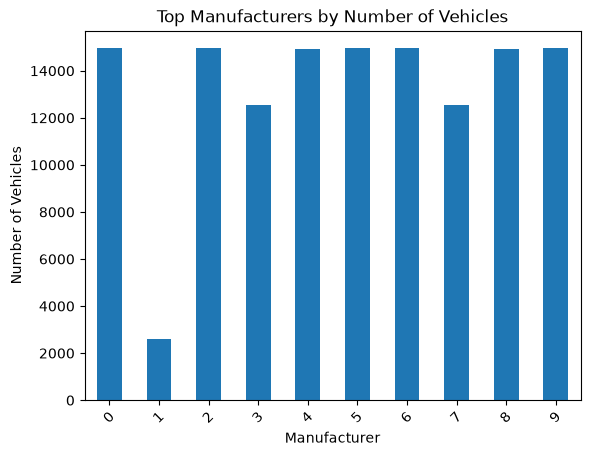

In [35]:
df['manufacturer_counts'].head(10).plot(kind='bar')
plt.title('Top Manufacturers by Number of Vehicles')
plt.xlabel('Manufacturer')
plt.ylabel('Number of Vehicles')
plt.xticks(rotation=45)
plt.show()

2. Which manufacturers have the highest average prices?

In [36]:
avg_price_manufacturer = (
    df.groupby('Manufacturer')['Price']
    .mean()
    .sort_values(ascending=False)
)

print(avg_price_manufacturer)

Manufacturer
Porsche    29103.764661
BMW        24429.459215
Toyota     14340.362275
Ford       10672.288723
VW         10363.139274
Name: Price, dtype: float64


In [37]:
print(avg_price_manufacturer.head(10))

Manufacturer
Porsche    29103.764661
BMW        24429.459215
Toyota     14340.362275
Ford       10672.288723
VW         10363.139274
Name: Price, dtype: float64


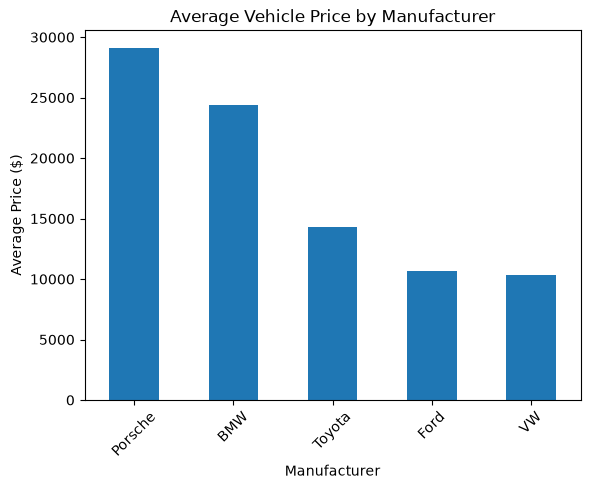

In [38]:
avg_price_manufacturer.head(10).plot(kind='bar')

plt.title('Average Vehicle Price by Manufacturer')
plt.xlabel('Manufacturer')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=45)
plt.show()

3. Which models are most expensive?

In [39]:
most_expensive = df.sort_values('Price', ascending=False)

print(most_expensive[['Manufacturer', 'Model', 'Price']].head(10))

      Manufacturer Model   Price
22786          BMW    M5  168081
14860          BMW    M5  168001
38438      Porsche   911  167774
49362      Porsche   911  164343
38166          BMW    M5  163608
24675          BMW    M5  159778
48704          BMW    M5  156952
39082          BMW    M5  156771
49500          BMW    M5  156219
43253          BMW    M5  156139


In [40]:
avg_price_model = (
    df.groupby('Model')['Price']
    .mean()
    .sort_values(ascending=False)
)

print(avg_price_model.head(10))

Model
M5            39911.110638
911           37024.724771
Cayenne       28714.568966
718 Cayman    21527.666667
RAV4          19433.170550
X3            17685.843137
Z4            15862.080569
Prius         14010.771038
Mondeo        12956.009292
Passat        12893.126052
Name: Price, dtype: float64


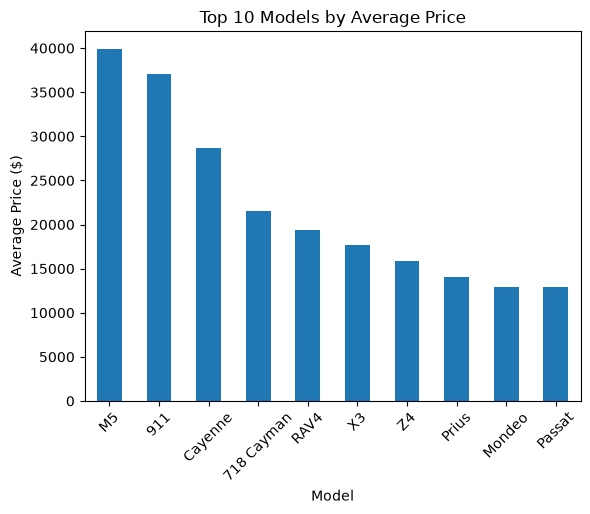

In [41]:
avg_price_model.head(10).plot(kind='bar')

plt.title('Top 10 Models by Average Price')
plt.xlabel('Model')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=45)
plt.show()

4. How does mileage affect price?

-0.6326917540945916


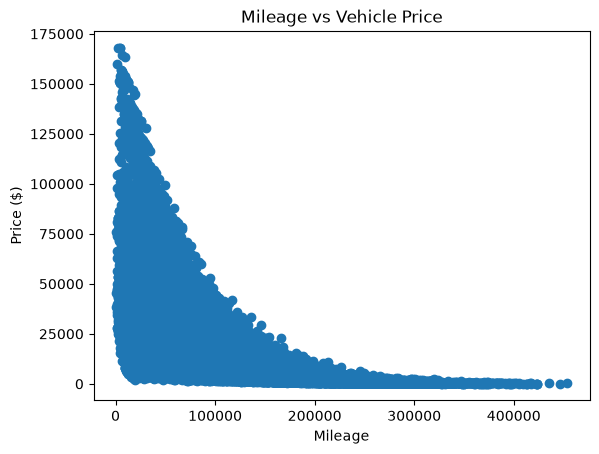

In [42]:
print(df['Mileage'].corr(df['Price']))
plt.scatter(df['Mileage'], df['Price'])

plt.title('Mileage vs Vehicle Price')
plt.xlabel('Mileage')
plt.ylabel('Price ($)')
plt.show()

5. How does vehicle age affect price?

-0.7142094051058944


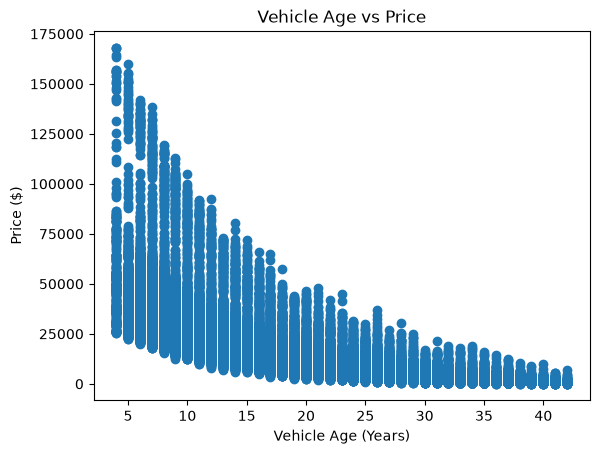

In [43]:
print(df['vehicle_age'].corr(df['Price']))
plt.scatter(df['vehicle_age'], df['Price'])
plt.title('Vehicle Age vs Price')
plt.xlabel('Vehicle Age (Years)')
plt.ylabel('Price ($)')
plt.show()

In [50]:
df['Engine_Size_counts'] = df['Engine size'].map(
    df['Engine size'].value_counts()
)
df.head()

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price,Current_Year,vehicle_age,Mileage_Per_Year,Price_Per_Mileage,total_vehicles,Average_Price,Median_Price,Average_Mileage,Average_age,average_engine_size,manufacturer_counts,Engine_Size_counts
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074,2026,24,5304.166667,0.024148,50000,13828.90316,7971.5,112497.3207,21.79056,1.773058,14959,6343
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704,2026,10,5785.000000,0.859188,50000,13828.90316,7971.5,112497.3207,21.79056,1.773058,2609,1092
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072,2026,12,3265.833333,0.614238,50000,13828.90316,7971.5,112497.3207,21.79056,1.773058,14959,5509
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705,2026,38,5547.736842,0.008088,50000,13828.90316,7971.5,112497.3207,21.79056,1.773058,12554,7032
4,VW,Polo,1.0,Petrol,2006,127869,4101,2026,20,6393.450000,0.032072,50000,13828.90316,7971.5,112497.3207,21.79056,1.773058,14913,6343


In [51]:
df['Fuel_type_count']= df['Fuel type'].map(
    df['Fuel type'].value_counts()
)
df.head()

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price,Current_Year,vehicle_age,Mileage_Per_Year,Price_Per_Mileage,total_vehicles,Average_Price,Median_Price,Average_Mileage,Average_age,average_engine_size,manufacturer_counts,Engine_Size_counts,Fuel_type_count
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074,2026,24,5304.166667,0.024148,50000,13828.90316,7971.5,112497.3207,21.79056,1.773058,14959,6343,25488
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704,2026,10,5785.000000,0.859188,50000,13828.90316,7971.5,112497.3207,21.79056,1.773058,2609,1092,25488
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072,2026,12,3265.833333,0.614238,50000,13828.90316,7971.5,112497.3207,21.79056,1.773058,14959,5509,13268
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705,2026,38,5547.736842,0.008088,50000,13828.90316,7971.5,112497.3207,21.79056,1.773058,12554,7032,11244
4,VW,Polo,1.0,Petrol,2006,127869,4101,2026,20,6393.450000,0.032072,50000,13828.90316,7971.5,112497.3207,21.79056,1.773058,14913,6343,25488


In [66]:
#saving cleaned dataset
df.to_csv("vehicle_pricing_cleaned.csv", index=False)

##DATA VALIDATION
The dataset was validated for data types, missing values, duplicate records, duplicate columns, invalid numerical values, categorical consistency, and potential outliers. No missing values or duplicate records were identified. Numerical variables including engine size, mileage, year of manufacture, and price were checked for invalid or non-positive values. Categorical variables were examined for inconsistent naming and formatting. Potential outliers in price and mileage were investigated and retained where they represented valid vehicle observations.

## BONUS- SELECTIVE VEHICLE PRICE MODEL

In [54]:
#Select X and Y
X = df[
    ['Manufacturer', 'Model', 'Engine size',
     'Fuel type', 'Year of manufacture', 'Mileage']
]

y = df['Price']

In [55]:

X = pd.get_dummies(
    X,
    columns=['Manufacturer', 'Model', 'Fuel type'],
    drop_first=True
)

In [56]:
#Train/ Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [57]:
#Training the model
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [58]:
#Make Predictions
y_pred = model.predict(X_test)

In [59]:
#Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 292.394788
RMSE: 644.2396938889593
R²: 0.9984705869992906
